In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Carregar os dados
df = pd.read_csv('../data/phishing_email_detection_2026_dataset.csv')

# 2. Primeira olhada nos dados
print("--- Informações Gerais ---")
print(df.info())

print("\n--- Resumo Estatístico ---")
print(df.describe())

--- Informações Gerais ---
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   email_id            1500 non-null   int64
 1   sender_email        1500 non-null   str  
 2   subject             1500 non-null   str  
 3   has_link            1500 non-null   int64
 4   has_attachment      1500 non-null   int64
 5   urgency_score       1500 non-null   int64
 6   spelling_errors     1500 non-null   int64
 7   email_length_words  1500 non-null   int64
 8   is_phishing         1500 non-null   int64
dtypes: int64(7), str(2)
memory usage: 105.6 KB
None

--- Resumo Estatístico ---
          email_id     has_link  has_attachment  urgency_score  \
count  1500.000000  1500.000000     1500.000000    1500.000000   
mean    750.500000     0.629333        0.512667       5.722667   
std     433.157015     0.483144        0.500006       3.002182   
min       1.0000

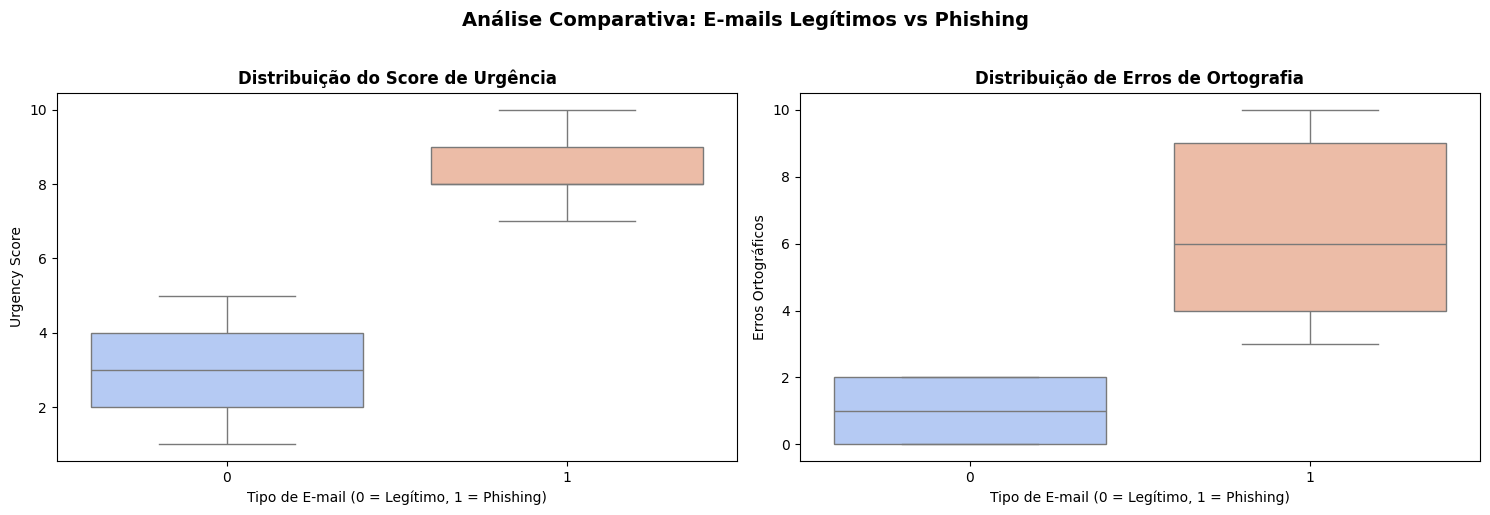

In [6]:
# 1. O fator Urgência e Erros Ortográficos
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot para Urgência (Ajustado)
sns.boxplot(
    ax=axes[0], 
    data=df, 
    x='is_phishing', 
    y='urgency_score', 
    hue='is_phishing', 
    palette='coolwarm', 
    legend=False
)
axes[0].set_title('Distribuição do Score de Urgência', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tipo de E-mail (0 = Legítimo, 1 = Phishing)')
axes[0].set_ylabel('Urgency Score')

# Boxplot para Erros Ortográficos (Ajustado)
sns.boxplot(
    ax=axes[1], 
    data=df, 
    x='is_phishing', 
    y='spelling_errors', 
    hue='is_phishing', 
    palette='coolwarm', 
    legend=False
)
axes[1].set_title('Distribuição de Erros de Ortografia', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tipo de E-mail (0 = Legítimo, 1 = Phishing)')
axes[1].set_ylabel('Erros Ortográficos')

plt.suptitle('Análise Comparativa: E-mails Legítimos vs Phishing', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# 2. Links e Anexos são determinantes?
# Proporção de links em e-mails normais vs phishing
link_phishing = pd.crosstab(df['has_link'], df['is_phishing'], normalize='columns') * 100
print("--- Porcentagem de Links por Tipo de E-mail ---")
print(link_phishing)

--- Porcentagem de Links por Tipo de E-mail ---
is_phishing          0          1
has_link                         
0            48.026316  25.810811
1            51.973684  74.189189


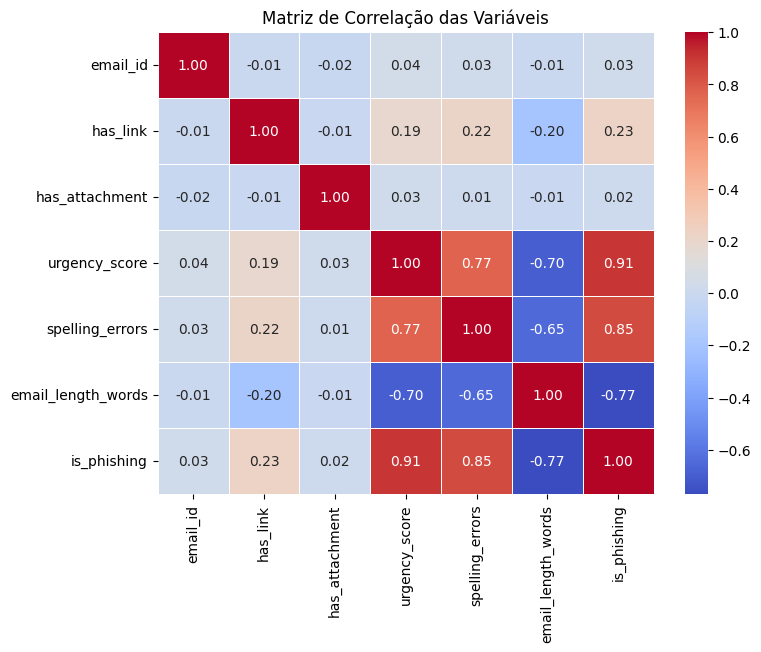

In [5]:
#3. Matriz de Correlação
plt.figure(figsize=(8, 6))
# Selecionando apenas colunas numéricas para a correlação
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação das Variáveis')
plt.show()

--- Novas Features Criadas! ---


,sender_email,email_domain,subject,subject_length
0,harrisonsandra@paypal-alert.com,paypal-alert.com,Meeting Reminder,16
1,randyharris@bankverify.net,bankverify.net,Urgent Account Verification,27
2,adam13@outlook.com,outlook.com,Suspicious Login Attempt,24
3,kennethfisher@company-secure.com,company-secure.com,Suspicious Login Attempt,24
4,wsandoval@paypal-alert.com,paypal-alert.com,Your Password Will Expire,25


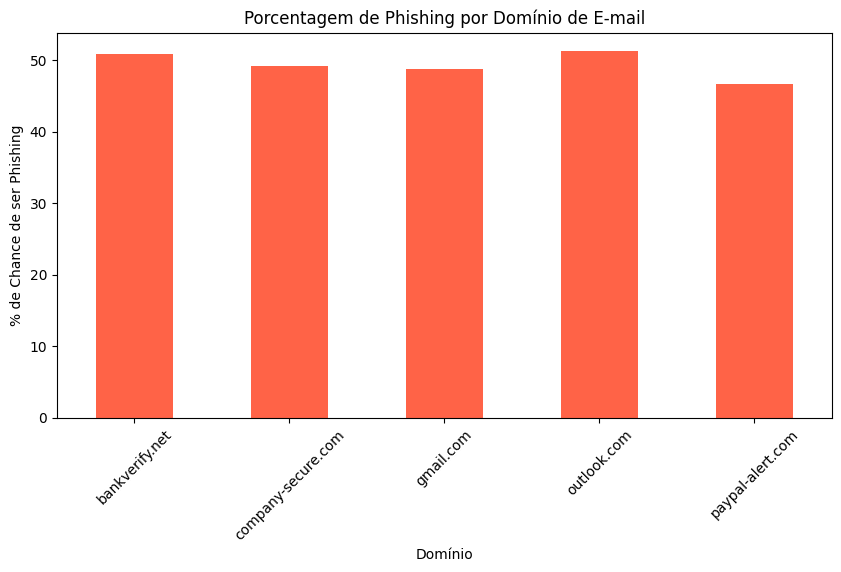

In [7]:
# Analise de dominio suspeito 
# Extraindo o domínio do remetente
df['email_domain'] = df['sender_email'].apply(lambda x: x.split('@')[1] if '@' in str(x) else 'unknown')

# Extraindo o tamanho do assunto
df['subject_length'] = df['subject'].str.len().fillna(0)

print("--- Novas Features Criadas! ---")
display(df[['sender_email', 'email_domain', 'subject', 'subject_length']].head())

# Análise de Domínios mais perigosos
plt.figure(figsize=(10, 5))
domain_phishing = pd.crosstab(df['email_domain'], df['is_phishing'], normalize='index') * 100
domain_phishing[1].plot(kind='bar', color='tomato')
plt.title('Porcentagem de Phishing por Domínio de E-mail')
plt.ylabel('% de Chance de ser Phishing')
plt.xlabel('Domínio')
plt.xticks(rotation=45)
plt.show()

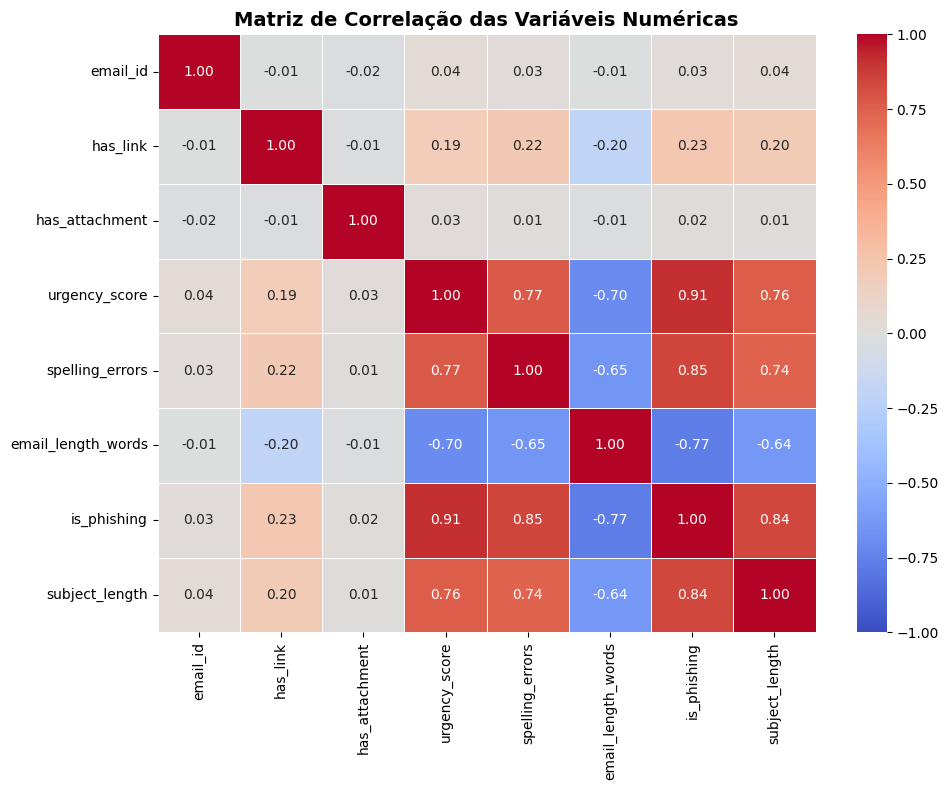

--- 🧠 Insights da Correlação ---
is_phishing           1.000000
urgency_score         0.908268
spelling_errors       0.846129
subject_length        0.842337
has_link              0.229962
email_id              0.027660
has_attachment        0.017678
email_length_words   -0.770694
Name: is_phishing, dtype: float64

--- 🛠️ Preparando os Dados para o Modelo (One-Hot Encoding) ---
Dataset pronto! Novo formato: 1500 linhas e 11 colunas.


,has_link,has_attachment,urgency_score,spelling_errors,email_length_words,is_phishing,subject_length,email_domain_company-secure.com,email_domain_gmail.com,email_domain_outlook.com,email_domain_paypal-alert.com
0,0,1,2,0,227,0,16,False,False,False,True
1,1,1,9,7,59,1,27,False,False,False,False
2,1,1,8,10,67,1,24,False,False,True,False
3,0,1,9,8,102,1,24,True,False,False,False
4,1,0,7,4,96,1,25,False,False,False,True


In [8]:
#Correlação Geral e Preparação para Machine Learning
# Cria a Matriz de Correlação apenas com as colunas que já são numéricas
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# Plotando o Heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação das Variáveis Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("--- 🧠 Insights da Correlação ---")
# Mostra quais variáveis têm maior correlação direta com o Phishing
print(corr_matrix['is_phishing'].sort_values(ascending=False))

print("\n--- 🛠️ Preparando os Dados para o Modelo (One-Hot Encoding) ---")
# Transforma a coluna de texto 'email_domain' em colunas binárias (0 ou 1)
df_ready = pd.get_dummies(df, columns=['email_domain'], drop_first=True)

# Remove as colunas de texto cruas que não usaremos mais no modelo
df_ready = df_ready.drop(columns=['email_id', 'sender_email', 'subject'])

print(f"Dataset pronto! Novo formato: {df_ready.shape[0]} linhas e {df_ready.shape[1]} colunas.")
display(df_ready.head())